# TFG Pipeline
Adrià Rojo, 2026

## Compilar eines

In [2]:
# SDModel
! g++ -O3 -std=c++17 -lboost_system -lboost_math_c99 SD-model/src/generatingSD_unix.cpp -o tools/genSD
# Mercator
! g++ -O3 -std=c++11 -I mercator/include/ mercator/src/embeddingS1_unix.cpp -o tools/mercator
# Epidemics
! gfortran -O3 -march=native -funroll-loops \
    ./epidemics-tfg/include/mt19937.f90 ./epidemics-tfg/include/mt19937_par.f90 ./epidemics-tfg/include/fhash.f90 \
    ./epidemics-tfg/include/net_loader.f90 ./epidemics-tfg/include/reversed_skiplist.f90 ./epidemics-tfg/include/epidemic.f90 \
    ./epidemics-tfg/main.f90 \
    -o ./tools/epidemics.out
! rm ./*.mod

In file included from /usr/include/boost/math/quadrature/gauss.hpp:15,
                 from SD-model/src/../include/generatingSD.hpp:40,
                 from SD-model/src/../include/generatingSD_unix.hpp:32,
                 from SD-model/src/generatingSD_unix.cpp:30:
/usr/include/boost/math/special_functions/legendre.hpp: In instantiation of ‘std::pair<_FIter, _FIter> boost::math::detail::legendre_p_zero_func<T, Policy>::operator()(T) const [with T = double; Policy = boost::math::policies::policy<boost::math::policies::default_policy, boost::math::policies::default_policy, boost::math::policies::default_policy, boost::math::policies::default_policy, boost::math::policies::default_policy, boost::math::policies::default_policy, boost::math::policies::default_policy, boost::math::policies::default_policy, boost::math::policies::default_policy, boost::math::policies::default_policy, boost::math::policies::default_policy>]’:
/usr/include/boost/math/tools/roots.hpp:259:29:   required from

In [4]:
! ./SD-model/genSD -h


NAME
  generatingSD -- a program to generate complex networks in the S^D metric space

SYNOPSIS
  generatingSD [options]
  

The following options are available:
  -b [BETA]        Specifies the value for parameter beta.
  -d [DIMENSION]   Specifies model's dimension (S^D).
  -g [GAMMA]       Exponent of the power-law distribution for hidden degrees.
  -n [SIZE]        Network size.
  -k [MEAN_DEGREE] Mean degree of nodes.
  -l [KAPPAS]      File consisting of the hidden degrees 
  -s [SEED]        Program uses a custom seed for the random number generator. Default: EPOCH.
  -v               Outputs the hidden variables (kappa and nodes'positions) used to the generate the network into a file (uses the edgelist's rootname).
  -h               Print this message on screen and exit.
  -o [FILENAME]    Name of the output file (without extension) (default: net)
  


In [60]:
! ./SD-model/genSD -d 1 -n 3000 -g 3 -k 6 -b 4 -s 12345 -o pipeline-output/net

OUTPUT_ROOTNAME = /home/adria/universitat/tfg/pipeline-output/net
edgelist_file = /home/adria/universitat/tfg/pipeline-output/net.edge


In [61]:
! ./mercator/mercator -o pipeline-output/ -g -b 4 -s 12345 ./pipeline-output/net_GC.edge

In [57]:
import numpy as np
import networkx as nx
import pandas as pd
def cart2pol(x, y):
    rho = np.sqrt(x**2 + y**2)
    phi = np.arctan2(y, x)
    return(rho, phi)

def pol2cart(rho, phi):
    x = rho * np.cos(phi)
    y = rho * np.sin(phi)
    return(x, y)

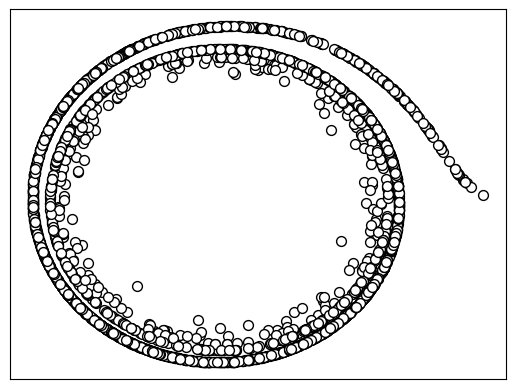

In [71]:
G = nx.read_edgelist("./pipeline-output/net_GC.edge")
pos = pd.read_csv("./pipeline-output/.inf_coord", sep='\\s+', comment='#', names=["Vertex", "Inf.Kappa", "Inf.Theta", "Inf.Hyp.Rad."])
positions_hyp = {v: (x, y) for v, x, y in zip(pos['Vertex'], pos['Inf.Hyp.Rad.'], pos['Inf.Kappa'])}

positions_cart = {v: pol2cart(x, y) for v, (x, y) in positions_hyp.items()}

nx.draw_networkx_nodes(G, pos=positions_cart, node_size=50, node_color='white', edgecolors='black')
    

In [ ]:

def lorentz_boost(x, target_point):
    """
    Aplica una transformación de Lorentz (boost) para centrar target_point en el origen.
    
    Parámetros:
    x: array de puntos en coordenadas del hiperboloide (n_samples, n_dim+1)
    target_point: punto que queremos llevar al origen (n_dim+1,)
    
    Retorna:
    x_boosted: puntos transformados con target_point en el origen
    """
    
    # Verificar dimensiones
    if len(x.shape) == 1:
        x = x.reshape(1, -1)
    
    # Obtener dimensiones
    n_dim = x.shape[1] - 1
    
    # Verificar que target_point está en el hiperboloide (norma de Minkowski = -1)
    norm_target = target_point[0]**2 - np.sum(target_point[1:]**2)
    if not np.isclose(norm_target, 1.0):
        print(f"Advertencia: norma de Minkowski = {norm_target}, debería ser 1")
    
    # Calcular parámetros del boost
    gamma = target_point[0]  # componente temporal
    
    # Vector beta (velocidad)
    beta = -target_point[1:] / gamma
    
    # Construir matriz de boost de Lorentz
    boost_matrix = np.zeros((n_dim+1, n_dim+1))
    
    # Componente temporal
    boost_matrix[0, 0] = gamma
    
    # Componentes mixtas (tiempo-espacio)
    boost_matrix[0, 1:] = gamma * beta
    boost_matrix[1:, 0] = gamma * beta
    
    # Componentes espaciales (parte de proyección)
    for i in range(n_dim):
        for j in range(n_dim):
            if i == j:
                boost_matrix[i+1, j+1] = 1 + (gamma - 1) * beta[i]**2 / np.dot(beta, beta)
            else:
                boost_matrix[i+1, j+1] = (gamma - 1) * beta[i] * beta[j] / np.dot(beta, beta)
    
    # Aplicar transformación
    x_boosted = x @ boost_matrix.T
    
    return x_boosted


def cartesian_to_hyperboloid(radial_positions):
    """
    Convierte posiciones radiales a coordenadas en el hiperboloide.
    
    Parámetros:
    radial_positions: array de distancias radiales (n_samples, n_dim)
    
    Retorna:
    hyperboloid_coords: coordenadas en el hiperboloide (n_samples, n_dim+1)
    """
    n_samples, n_dim = radial_positions.shape
    
    # Calcular coordenadas en el hiperboloide: (cosh(r), sinh(r) * dirección unitaria)
    r = np.linalg.norm(radial_positions, axis=1)
    
    # Evitar división por cero
    mask = r > 0
    directions = np.zeros_like(radial_positions)
    directions[mask] = radial_positions[mask] / r[mask][:, np.newaxis]
    
    # Crear coordenadas del hiperboloide
    hyperboloid_coords = np.zeros((n_samples, n_dim + 1))
    hyperboloid_coords[:, 0] = np.cosh(r)
    hyperboloid_coords[:, 1:] = directions * np.sinh(r)[:, np.newaxis]
    
    return hyperboloid_coords


def hyperboloid_to_cartesian(hyperboloid_coords):
    """
    Convierte coordenadas del hiperboloide de vuelta a posiciones radiales.
    
    Parámetros:
    hyperboloid_coords: coordenadas en el hiperboloide (n_samples, n_dim+1)
    
    Retorna:
    radial_positions: posiciones radiales (n_samples, n_dim)
    """
    # Extraer r de las coordenadas
    r = np.arccosh(hyperboloid_coords[:, 0])
    
    # Obtener direcciones
    sinh_r = np.sinh(r)
    directions = np.zeros((hyperboloid_coords.shape[0], hyperboloid_coords.shape[1]-1))
    
    mask = sinh_r > 0
    directions[mask] = hyperboloid_coords[mask, 1:] / sinh_r[mask][:, np.newaxis]
    
    # Posiciones radiales
    radial_positions = directions * r[:, np.newaxis]
    
    return radial_positions


def centrar_punto_espacio_hiperbolico(posiciones_radiales: dict, key_to_center):
    """
    Función principal: centra un punto específico en el espacio hiperbólico.
    
    Parámetros:
    posiciones_radiales: array de posiciones radiales (n_samples x n_dim)
    indice_a_centrar: índice del punto que queremos llevar al origen
    
    Retorna:
    posiciones_centradas: nuevas posiciones radiales con el punto centrado
    matriz_transformacion: matriz de boost utilizada
    """
    # Convertir a coordenadas del hiperboloide
    hiperboloide_coords = {cartesian_to_hyperboloid(posiciones_radiales)}
    
    # Obtener el punto a centrar
    punto_a_centrar = hiperboloide_coords[key_to_center].copy()
    
    # Aplicar boost de Lorentz para centrar el punto
    hiperboloide_centrado = lorentz_boost(hiperboloide_coords, punto_a_centrar)
    
    # Convertir de vuelta a posiciones radiales
    posiciones_centradas = hyperboloid_to_cartesian(hiperboloide_centrado)
    
    return posiciones_centradas

In [89]:
ks = nx.degree(G)
max_k_node = max(dict(ks).items(), key=lambda x: x[1])
max_k_pos = positions_hyp[max_k_node[0]]
display(max_k_node[0])
display(max_k_pos)
positions_lorentz_only = lorentz_boost(np.array(list(positions_hyp.values())), np.array(max_k_pos))
positions_lorentz = {k: (x, y) for k, (x, y) in zip(positions_hyp.keys(), positions_lorentz_only)}
positions_lorentz['v996']

'v996'

(15.9781, 144.161)

Advertencia: norma de Minkowski = -20527.094241389997, debería ser 1


(np.float64(-20527.09424139), np.float64(1.4163991011173493e-13))

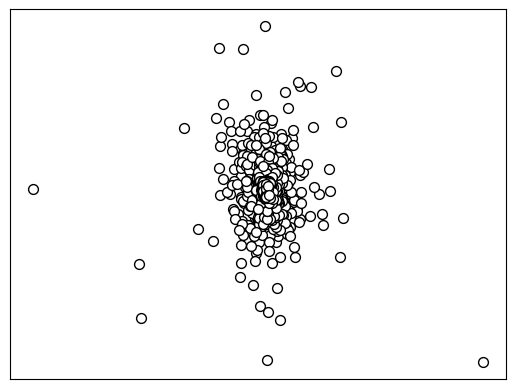

In [86]:
positions_cart = {v: pol2cart(x, y) for v, (x, y) in positions_lorentz.items()}
nx.draw_networkx_nodes(G, pos=positions_cart, node_size=50, node_color='white', edgecolors='black')